# Contour plots

This example shows how to make contour plots for data defined on the faces of datasets.

Contour plots in matplotlib must be defined on regular grid, or on a triangulation.
We opt to work with a triangulation.

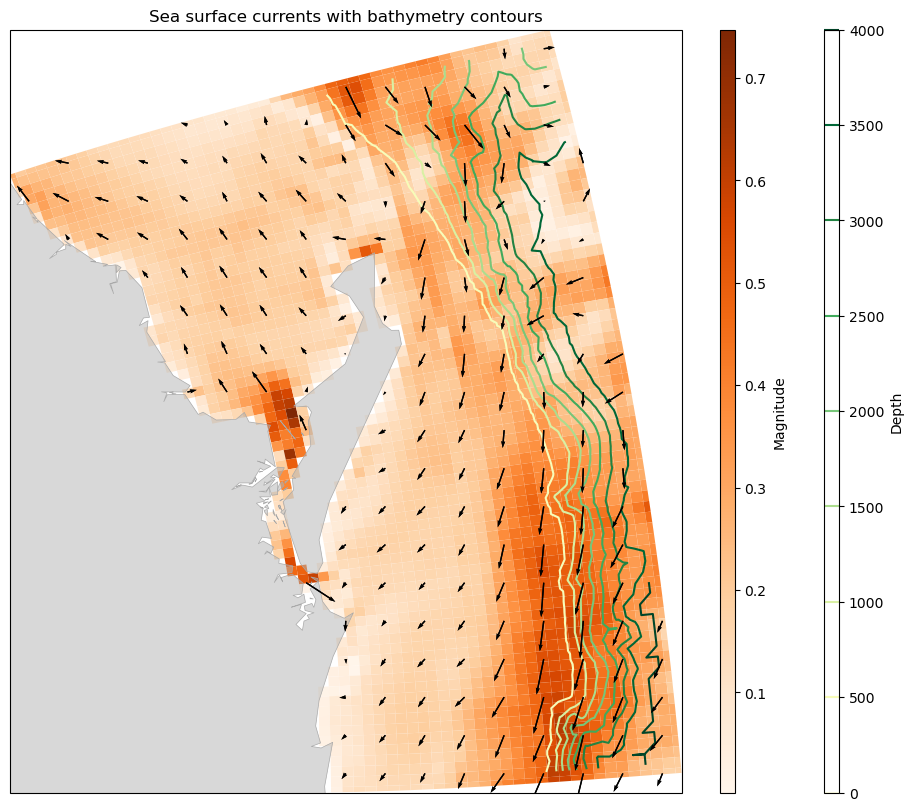

In [19]:
import emsarray
import emsarray.plot
import matplotlib.pyplot as plt
import numpy
import pandas
import shapely
import shapely.geometry
from emsarray.operations import point_extraction
from matplotlib.tri import Triangulation
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.collections import PatchCollection


# Open the dataset and select some variables
ds = emsarray.tutorial.open_dataset("kgari")
botz = ds['botz']
# levels = [0, 200, 400, 600, 800, 1000]

latest_surface_currents = ds.ems.select_variables(['u', 'v']).isel(time=-1, k=-1)
u = latest_surface_currents['u']
v = latest_surface_currents['v']
magnitude = numpy.sqrt(u ** 2 + v ** 2)

# Where to plot. Default to the entire dataset extent.
# Tuple of (min x, min y, max x, max y)
view_box = ds.ems.bounds


def triangulate_face_centres(dataset):
    # Compute the Delaunay triangulation of the face centres
    face_centres = dataset.ems.face_centres[dataset.ems.mask]
    triangulation = Triangulation(face_centres[:, 0], face_centres[:, 1])

    # Mask out any Triangles that are not contained within the dataset geometry.
    # These are either in concave areas of the geometry (e.g. an inlet or bay)
    # or cover holes in the geometry (e.g. islands).
    valid_tris = dataset.ems.geometry.contains(shapely.polygons([
        [[triangulation.x[i], triangulation.y[i]] for i in tri]
        for tri in triangulation.triangles
    ]))
    triangulation.set_mask(~valid_tris)

    return triangulation


def make_tricontour(axes, dataset, data_array, **kwargs):
    # Plot a contour of the bathymetry
    triangulation = triangulate_face_centres(dataset)
    values = dataset.ems.ravel(data_array).values[dataset.ems.mask]
    
    # tricontour does _not_ handle nans, so we need to mask these out first.
    # The mask applies to triangles, but it is the vertices that have nans.
    # We need to find all nan vertices,
    # then find all triangles that use one of those vertices,
    # then mask out those triangles,
    # while also not clobbering the existing mask that removes triangles outside the geometry.
    invalid_indices = numpy.flatnonzero(~numpy.isfinite(values))
    invalid_tris = numpy.any(numpy.isin(triangulation.triangles, invalid_indices), axis=1)
    triangulation.set_mask(triangulation.mask | invalid_tris)
    
    return axes.tricontour(triangulation, values, **kwargs)


def extract_regular_points(dataset, view_box, spacing=None):
    # Generate some points in a view box and extract the current vectors.
    if spacing is None:
        # Calculate some quiver spacing automatically.
        # This gives a spacing that feels nice to me,
        # but `2.5` is entirely arbitrary otherwise.
        spacing = max(
            (view_box[2] - view_box[0]) / figure.get_figwidth(),
            (view_box[3] - view_box[1]) / figure.get_figheight(),
        ) / 2.5

    padding = (spacing / 2) * numpy.array([1, 1, -1, -1])
    bounds = padding + view_box

    lons, lats = numpy.meshgrid(
        numpy.linspace(
            bounds[0], bounds[2],
            int(numpy.ceil((bounds[2] - bounds[0]) / spacing)),
        ),
        numpy.linspace(
            bounds[1], bounds[3],
            int(numpy.ceil((bounds[3] - bounds[1]) / spacing)),
        ),
    )

    dataset.load()
    return point_extraction.extract_dataframe(
        dataset,
        pandas.DataFrame({'lon': lons.flat, 'lat': lats.flat}),
        ('lon', 'lat'),
        missing_points='drop',
    )


# The stacking order of various plot elements
z_scalar = 1.0
z_coast = 1.5
z_overlay = 2.0


figure = plt.figure(figsize=(10, 8), layout='constrained')
axes = figure.add_subplot(projection=ds.ems.data_crs)
axes.set_title("Sea surface currents with bathymetry contours")


emsarray.plot.add_coast(axes, zorder=z_coast)

contour = make_tricontour(
    axes, ds, botz, 
    cmap='YlGn', zorder=z_overlay)
figure.colorbar(contour, label='Depth', aspect=50)


# Plot the current magnitude
collection = ds.ems.make_poly_collection(
    magnitude,
    cmap='Oranges', zorder=z_scalar)
axes.add_collection(collection)
figure.colorbar(collection, label='Magnitude', aspect=50)


# Plot the current vectors
points = extract_regular_points(latest_surface_currents, view_box)
quiver = axes.quiver(
    points['lon'], points['lat'], points['u'], points['v'],
    scale=10, scale_units='width', zorder=z_overlay,
    width=0.002)
axes.add_collection(quiver)


axes.set_extent(emsarray.plot.bounds_to_extent(view_box), crs=ds.ems.data_crs)


plt.show()